In [2]:
# Import core data manipulation and scientific libraries
import pandas as pd
import numpy as np

# For generating fake realistic data (names, addresses, etc.)
from faker import Faker

# For date/time manipulation
from datetime import datetime, timedelta
import random

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For preprocessing and modeling 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Set a seed for reproducibility
np.random.seed(42)
random.seed(42)
Faker.seed(42)

# Initialize Faker
fake = Faker()

print("Libraries imported successfully. Seed set to 42.")

Libraries imported successfully. Seed set to 42.


In [3]:
# ======================
# CONFIGURATION PARAMETERS
# ======================
NUM_CUSTOMERS = 50000          # Number of unique users
NUM_PRODUCTS = 100             # Size of the product catalog
START_DATE = datetime(2024, 1, 1, 0, 0, 0)  # Start of data
END_DATE = datetime(2025, 12, 31, 23, 59, 59) # End of data
DAYS_OF_DATA = (END_DATE - START_DATE).days  # ~730 days

print(f"Generating data for {NUM_CUSTOMERS} customers over {DAYS_OF_DATA} days.")

Generating data for 50000 customers over 730 days.


In [4]:
# Create a product catalog
categories = ['Electronics', 'Clothing', 'Home & Kitchen', 'Books']
products = []

for i in range(NUM_PRODUCTS):
    category = np.random.choice(categories)
    # Assign prices based on category to make it realistic
    if category == 'Electronics':
        price = round(np.random.uniform(50, 1200), 2)
    elif category == 'Clothing':
        price = round(np.random.uniform(15, 150), 2)
    elif category == 'Home & Kitchen':
        price = round(np.random.uniform(20, 400), 2)
    else: # Books
        price = round(np.random.uniform(10, 60), 2)
        
    products.append({
        'product_id': i + 1,
        'product_name': fake.catch_phrase(), # Fake product name
        'category': category,
        'base_price': price
    })

products_df = pd.DataFrame(products)
print("Product Catalog created:")
products_df.head()

Product Catalog created:


,product_id,product_name,category,base_price
0,1,Sharable bifurcated algorithm,Home & Kitchen,322.69
1,2,User-centric even-keeled encryption,Home & Kitchen,298.16
2,3,Face-to-face client-driven support,Electronics,736.38
3,4,Customer-focused systematic support,Clothing,36.06
4,5,Quality-focused background parallelism,Home & Kitchen,194.51


In [5]:
customers = []
for i in range(NUM_CUSTOMERS):
    # Account created at some random point in the last 2 years
    days_ago = np.random.randint(1, DAYS_OF_DATA)
    account_created = START_DATE + timedelta(days=days_ago)
    
    # Demographics
    age = np.random.randint(18, 70)
    # Income loosely correlated with age (just for realistic variance)
    income = np.random.normal(50000 + (age * 500), 15000)
    income = max(20000, min(200000, int(income))) # Clamp between 20k and 200k
    
    customers.append({
        'customer_id': i + 1,
        'age': age,
        'gender': np.random.choice(['Male', 'Female', 'Non-Binary']),
        'location': fake.state_abbr(),
        'income': income,
        'account_created_date': account_created
    })

customers_df = pd.DataFrame(customers)
print("Customer Demographics created:")
customers_df.head()

Customer Demographics created:


,customer_id,age,gender,location,income,account_created_date
0,1,18,Female,SD,50379,2024-08-13
1,2,23,Non-Binary,CT,55177,2025-11-03
2,3,28,Female,AR,44171,2025-03-15
3,4,22,Female,MO,50976,2024-10-07
4,5,39,Male,VA,56290,2024-07-17


In [8]:
# Generate Customer Activity 

from tqdm import tqdm  # For progress bars


NUM_CUSTOMERS = 5000  # data size
DAYS_PER_CUSTOMER = 365  # duration

print(f"Generating activity for {NUM_CUSTOMERS} customers over {DAYS_PER_CUSTOMER} days...")

# build a list of dictionaries for each interaction
activities = []

# Assign each customer a baseline activity level (0.2 to 0.9) to differentiate users
activity_levels = np.random.beta(2, 2, NUM_CUSTOMERS)

# Progress bar for customers
for idx in tqdm(range(NUM_CUSTOMERS), desc="Processing customers"):
    customer_id = idx + 1
    row = customers_df.iloc[idx]
    account_date = row['account_created_date']
    activity_base = activity_levels[idx]
    
    # Number of days this customer has been active (cap at 365 for performance)
    active_days = min((END_DATE - account_date).days, DAYS_PER_CUSTOMER)
    if active_days <= 0:
        continue
        
    # Simulate daily activity
    for day_offset in range(active_days):
        current_date = account_date + timedelta(days=day_offset)
        
        # Browsing: Poisson distribution. Average views per day = 2 * activity_base
        page_views = np.random.poisson(2 * activity_base)
        
        # Purchasing: Probability of buying on any given day is 5% * activity_base
        if np.random.random() < (0.05 * activity_base):
            # Customer made a purchase
            product_chosen = products_df.sample(1).iloc[0]
            # Add a slight discount or markup randomly
            price_paid = product_chosen['base_price'] * np.random.uniform(0.85, 1.0)
            price_paid = round(price_paid, 2)
            
            activities.append({
                'customer_id': customer_id,
                'date': current_date,
                'event_type': 'purchase',
                'product_id': product_chosen['product_id'],
                'price': price_paid,
                'page_views': page_views
            })
        else:
            # Just browsing (or add to cart without buying)
            if page_views > 0:
                # 30% chance they view a specific product page if browsing
                product_viewed = products_df.sample(1).iloc[0]['product_id'] if np.random.random() < 0.3 else None
                activities.append({
                    'customer_id': customer_id,
                    'date': current_date,
                    'event_type': 'browse',
                    'product_id': product_viewed,
                    'price': None,
                    'page_views': page_views
                })

print(f"Generated {len(activities)} activity records.")

Generating activity for 5000 customers over 365 days...


Processing customers: 100%|███████████| 5000/5000 [08:05<00:00, 10.30it/s]

Generated 822799 activity records.


In [9]:
# ============================================
#  Convert to DataFrame and Save
# ============================================

print("Converting activities to DataFrame...")
activity_df = pd.DataFrame(activities)

print(f"Raw activity DataFrame shape: {activity_df.shape}")

# Merge with product info to get category and base price for purchases
print("Merging with product catalog...")
activity_df = activity_df.merge(products_df[['product_id', 'category', 'base_price']], 
                                on='product_id', how='left')

# Merge with customer demographics
print("Merging with customer demographics...")
activity_df = activity_df.merge(customers_df, on='customer_id', how='left')

# Sort for readability
activity_df = activity_df.sort_values(['customer_id', 'date']).reset_index(drop=True)

# Save to CSV
print("Saving to CSV...")
activity_df.to_csv('ecommerce_synthetic_data.csv', index=False)
customers_df.to_csv('ecommerce_customers.csv', index=False)
products_df.to_csv('ecommerce_products.csv', index=False)

# Display summary statistics
print("\n" + "="*50)
print("DATASET GENERATION COMPLETE!")
print("="*50)
print(f"Total records generated: {len(activity_df):,}")
print(f"Unique customers: {activity_df['customer_id'].nunique():,}")
print(f"Date range: {activity_df['date'].min()} to {activity_df['date'].max()}")
print(f"\nEvent type breakdown:")
print(activity_df['event_type'].value_counts())
print(f"\nCategory breakdown:")
print(activity_df['category'].value_counts())

print("\nFirst 5 rows of the dataset:")
activity_df.head()

Converting activities to DataFrame...
Raw activity DataFrame shape: (822799, 6)
Merging with product catalog...
Merging with customer demographics...
Saving to CSV...

DATASET GENERATION COMPLETE!
Total records generated: 822,799
Unique customers: 4,997
Date range: 2024-01-02 00:00:00 to 2025-12-30 00:00:00

Event type breakdown:
event_type
browse      788469
purchase     34330
Name: count, dtype: int64

Category breakdown:
category
Home & Kitchen    75658
Clothing          72820
Books             62524
Electronics       59907
Name: count, dtype: int64

First 5 rows of the dataset:


,customer_id,date,event_type,product_id,price,page_views,category,base_price,age,gender,location,income,account_created_date
0,1,2024-08-16,browse,NaN,NaN,2,NaN,NaN,18,Female,SD,50379,2024-08-13
1,1,2024-08-17,browse,58.0,NaN,1,Electronics,889.05,18,Female,SD,50379,2024-08-13
2,1,2024-08-18,browse,NaN,NaN,2,NaN,NaN,18,Female,SD,50379,2024-08-13
3,1,2024-08-19,browse,48.0,NaN,1,Electronics,278.52,18,Female,SD,50379,2024-08-13
4,1,2024-08-20,browse,29.0,NaN,1,Home & Kitchen,85.88,18,Female,SD,50379,2024-08-13


In [10]:
# ============================================
#  Load Data & Initial Inspection
# ============================================

# Load the generated data (if you're starting fresh)
df = pd.read_csv('ecommerce_synthetic_data.csv', parse_dates=['date'])

# Display basic information
print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Dataset shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
print("\nColumn data types:")
print(df.dtypes)

print("\nFirst 5 rows:")
df.head()

print("\nMissing values per column:")
print(df.isnull().sum())

DATASET OVERVIEW
Dataset shape: 822,799 rows, 13 columns

Column data types:
customer_id                      int64
date                    datetime64[us]
event_type                         str
product_id                     float64
price                          float64
page_views                       int64
category                           str
base_price                     float64
age                              int64
gender                             str
location                           str
income                           int64
account_created_date               str
dtype: object

First 5 rows:

Missing values per column:
customer_id                  0
date                         0
event_type                   0
product_id              551890
price                   788469
page_views                   0
category                551890
base_price              551890
age                          0
gender                       0
location                     0
income            

In [11]:
# ============================================
# Statistical Summary
# ============================================

print("="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)

# Numerical columns
numerical_cols = ['age', 'income', 'price', 'page_views', 'base_price']
print("\nNumerical columns summary:")
print(df[numerical_cols].describe())

# Categorical columns
categorical_cols = ['gender', 'location', 'category', 'event_type']
print("\nCategorical columns summary:")
for col in categorical_cols:
    print(f"\n{col.upper()} distribution:")
    print(df[col].value_counts().head(10))

DESCRIPTIVE STATISTICS

Numerical columns summary:
                 age         income         price     page_views  \
count  822799.000000  822799.000000  34330.000000  822799.000000   
mean       43.120859   71846.304347    192.068401       1.663401   
std        14.997072   16729.405729    247.289758       0.948390   
min        18.000000   20000.000000      9.100000       0.000000   
25%        30.000000   60111.000000     43.300000       1.000000   
50%        43.000000   72126.000000    106.515000       1.000000   
75%        56.000000   83447.000000    249.477500       2.000000   
max        69.000000  128503.000000   1196.940000      11.000000   

          base_price  
count  270909.000000  
mean      208.188782  
std       266.828222  
min        10.700000  
25%        46.860000  
50%       113.180000  
75%       278.520000  
max      1197.400000  

Categorical columns summary:

GENDER distribution:
gender
Male          286024
Female        275370
Non-Binary    261405
Name: c

In [12]:
# ============================================
#  Data Cleaning
# ============================================

print("="*60)
print("DATA CLEANING")
print("="*60)

# 1. Check for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Removed {duplicates} duplicates. New shape: {df.shape}")

# 2. Handle missing values
print("\nMissing values before cleaning:")
print(df.isnull().sum())

# For 'price' column: fill with 0 for browse events (no purchase price)
df['price'] = df['price'].fillna(0)

# For 'product_id' and 'category' in browse events: fill with 'unknown'
df['product_id'] = df['product_id'].fillna(0).astype(int)
df['category'] = df['category'].fillna('unknown')
df['base_price'] = df['base_price'].fillna(0)

# Check if any missing values remain
print("\nMissing values after cleaning:")
print(df.isnull().sum())

# 3. Check for outliers 
print("\nChecking for outliers in price...")
Q1 = df[df['event_type'] == 'purchase']['price'].quantile(0.25)
Q3 = df[df['event_type'] == 'purchase']['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['event_type'] == 'purchase') & ((df['price'] < lower_bound) | (df['price'] > upper_bound))]
print(f"Outliers in purchase price: {len(outliers)} rows")

print(f"\nDataset after cleaning: {df.shape[0]:,} rows, {df.shape[1]} columns")

DATA CLEANING
Duplicate rows found: 0

Missing values before cleaning:
customer_id                  0
date                         0
event_type                   0
product_id              551890
price                   788469
page_views                   0
category                551890
base_price              551890
age                          0
gender                       0
location                     0
income                       0
account_created_date         0
dtype: int64

Missing values after cleaning:
customer_id             0
date                    0
event_type              0
product_id              0
price                   0
page_views              0
category                0
base_price              0
age                     0
gender                  0
location                0
income                  0
account_created_date    0
dtype: int64

Checking for outliers in price...
Outliers in purchase price: 3050 rows

Dataset after cleaning: 822,799 rows, 13 columns


In [13]:
df

,customer_id,date,event_type,product_id,price,page_views,category,base_price,age,gender,location,income,account_created_date
0,1,2024-08-16,browse,0,0.00,2,unknown,0.00,18,Female,SD,50379,2024-08-13
1,1,2024-08-17,browse,58,0.00,1,Electronics,889.05,18,Female,SD,50379,2024-08-13
2,1,2024-08-18,browse,0,0.00,2,unknown,0.00,18,Female,SD,50379,2024-08-13
3,1,2024-08-19,browse,48,0.00,1,Electronics,278.52,18,Female,SD,50379,2024-08-13
4,1,2024-08-20,browse,29,0.00,1,Home & Kitchen,85.88,18,Female,SD,50379,2024-08-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...
822794,5000,2025-12-24,browse,48,0.00,1,Electronics,278.52,50,Female,WY,65647,2025-06-22
822795,5000,2025-12-26,browse,0,0.00,5,unknown,0.00,50,Female,WY,65647,2025-06-22
822796,5000,2025-12-27,browse,30,0.00,2,Electronics,347.60,50,Female,WY,65647,2025-06-22
822797,5000,2025-12-29,purchase,93,116.28,2,Electronics,124.63,50,Female,WY,65647,2025-06-22


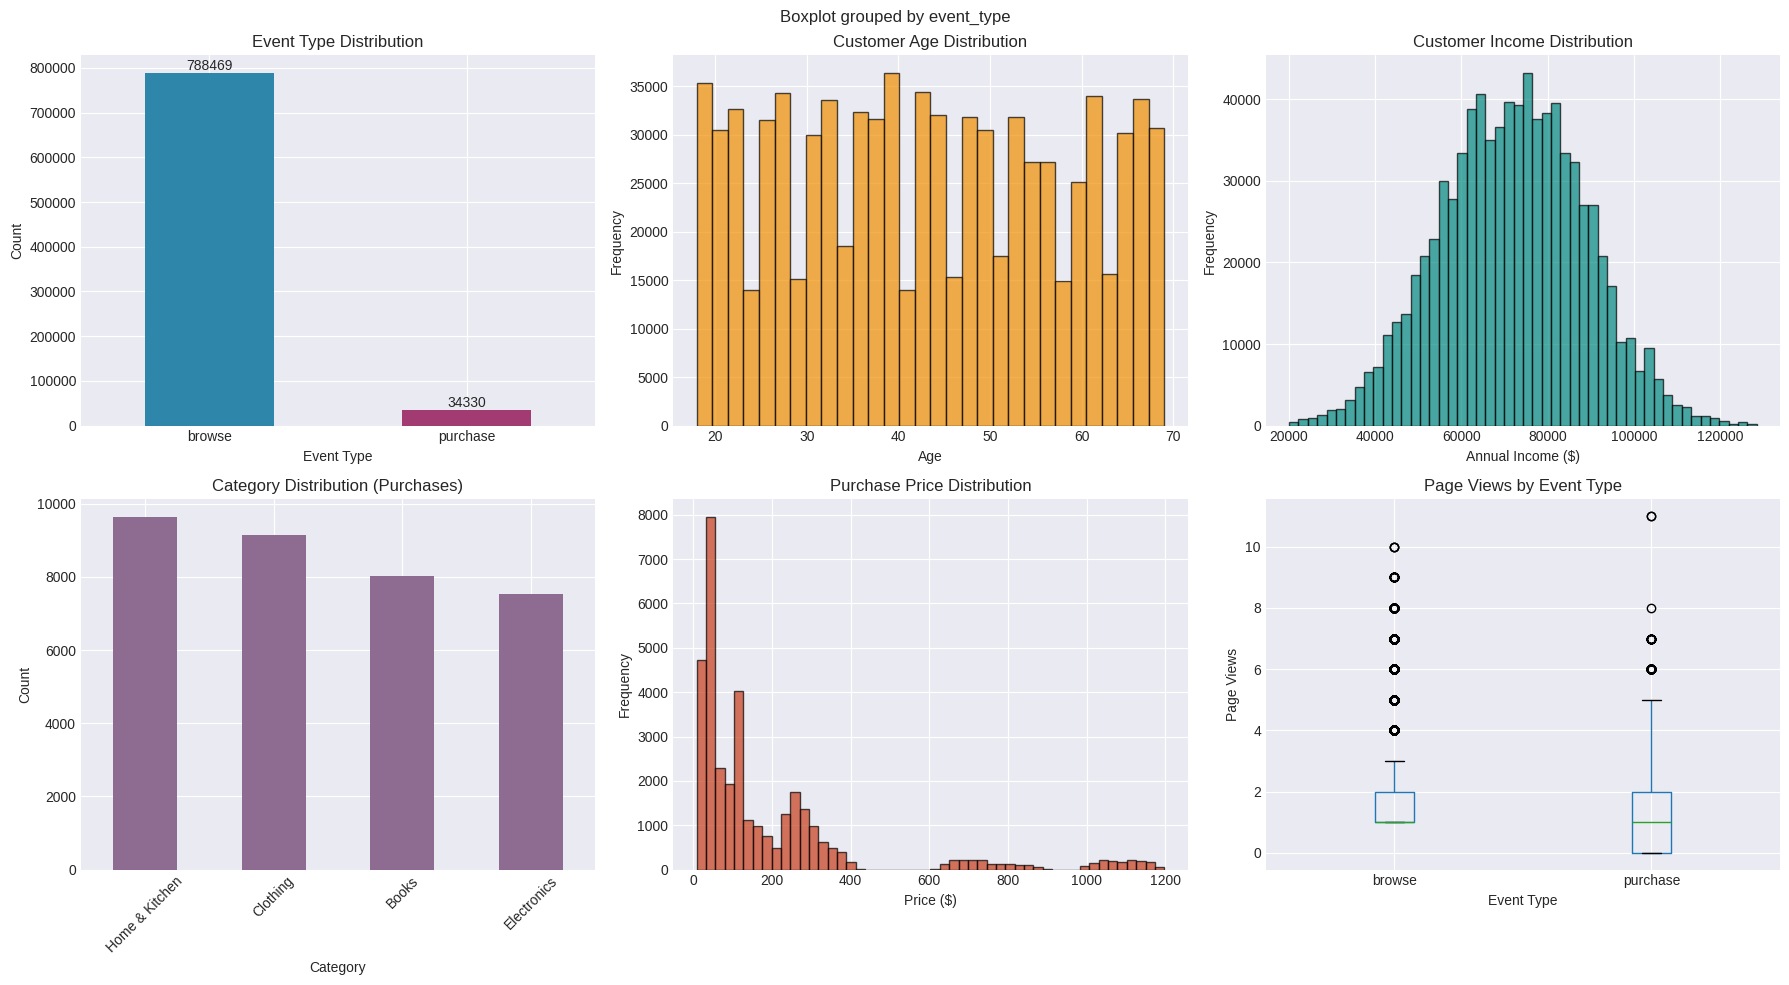

In [14]:
# ============================================
#  EDA Visualizations
# ============================================

# Set up the plotting style
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Exploratory Data Analysis', fontsize=16, fontweight='bold')

# 1. Event type distribution
df['event_type'].value_counts().plot(kind='bar', ax=axes[0, 0], color=['#2E86AB', '#A23B72'])
axes[0, 0].set_title('Event Type Distribution')
axes[0, 0].set_xlabel('Event Type')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=0)
for i, v in enumerate(df['event_type'].value_counts()):
    axes[0, 0].text(i, v + 100, str(v), ha='center', va='bottom')

# 2. Age distribution
df['age'].hist(bins=30, ax=axes[0, 1], color='#F18F01', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Customer Age Distribution')
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Frequency')

# 3. Income distribution
df['income'].hist(bins=50, ax=axes[0, 2], color='#048A81', edgecolor='black', alpha=0.7)
axes[0, 2].set_title('Customer Income Distribution')
axes[0, 2].set_xlabel('Annual Income ($)')
axes[0, 2].set_ylabel('Frequency')

# 4. Category distribution (for purchases only)
purchase_df = df[df['event_type'] == 'purchase']
purchase_df['category'].value_counts().plot(kind='bar', ax=axes[1, 0], color='#8E6B90')
axes[1, 0].set_title('Category Distribution (Purchases)')
axes[1, 0].set_xlabel('Category')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# 5. Price distribution (for purchases)
purchase_df['price'].hist(bins=50, ax=axes[1, 1], color='#C73E1D', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Purchase Price Distribution')
axes[1, 1].set_xlabel('Price ($)')
axes[1, 1].set_ylabel('Frequency')

# 6. Page views by event type
df.boxplot(column='page_views', by='event_type', ax=axes[1, 2])
axes[1, 2].set_title('Page Views by Event Type')
axes[1, 2].set_xlabel('Event Type')
axes[1, 2].set_ylabel('Page Views')

plt.tight_layout()
plt.show()

In [15]:
# ============================================
#  Feature Engineering - Customer Aggregates
# ============================================

print("="*60)
print("FEATURE ENGINEERING - CUSTOMER AGGREGATES")
print("="*60)

# Group by customer to create aggregate features
customer_features = df.groupby('customer_id').agg({
    'event_type': [
        ('total_purchases', lambda x: (x == 'purchase').sum()),
        ('total_browses', lambda x: (x == 'browse').sum())
    ],
    'price': [
        ('total_spent', 'sum'),
        ('avg_order_value', 'mean')
    ],
    'page_views': [
        ('total_page_views', 'sum'),
        ('avg_page_views', 'mean')
    ],
    'date': [
        ('first_activity', 'min'),
        ('last_activity', 'max')
    ]
}).reset_index()

# Flatten multi-level columns
customer_features.columns = ['customer_id', 'total_purchases', 'total_browses', 
                             'total_spent', 'avg_order_value', 
                             'total_page_views', 'avg_page_views',
                             'first_activity', 'last_activity']

# Calculate additional features
customer_features['first_activity'] = pd.to_datetime(customer_features['first_activity'])
customer_features['last_activity'] = pd.to_datetime(customer_features['last_activity'])

# Days since first and last activity (relative to end date)
end_date = df['date'].max()
customer_features['days_since_first'] = (end_date - customer_features['first_activity']).dt.days
customer_features['days_since_last'] = (end_date - customer_features['last_activity']).dt.days

# Customer lifetime (in days)
customer_features['customer_lifetime_days'] = (customer_features['last_activity'] - customer_features['first_activity']).dt.days

# Average daily activity
customer_features['avg_daily_activity'] = (customer_features['total_purchases'] + customer_features['total_browses']) / \
                                          customer_features['customer_lifetime_days'].clip(lower=1)

# Purchase conversion rate
customer_features['purchase_conversion_rate'] = customer_features['total_purchases'] / \
                                                (customer_features['total_purchases'] + customer_features['total_browses']).clip(lower=1)

print("Customer-level features created:")
customer_features.head(10)

# Merge with customer demographics
customer_features = customer_features.merge(df[['customer_id', 'age', 'gender', 'location', 'income']].drop_duplicates(), 
                                            on='customer_id', how='left')

print(f"\nFinal customer features shape: {customer_features.shape}")

FEATURE ENGINEERING - CUSTOMER AGGREGATES
Customer-level features created:

Final customer features shape: (4997, 18)


In [16]:
# ============================================
#  Feature Engineering - Time-Based Features
# ============================================

print("="*60)
print("FEATURE ENGINEERING - TIME-BASED FEATURES")
print("="*60)

# Extract time features from the date column
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek  # 0=Monday, 6=Sunday
df['quarter'] = df['date'].dt.quarter
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# Season (based on month)
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['season'] = df['month'].apply(get_season)

print("Time-based features added to main dataset:")
print(df[['date', 'year', 'month', 'day', 'day_of_week', 'is_weekend', 'quarter', 'season']].head())

# Analyze seasonality in purchases
seasonal_purchases = df[df['event_type'] == 'purchase'].groupby(['season', 'category']).size().unstack()
print("\nSeasonal purchase patterns:")
print(seasonal_purchases)

FEATURE ENGINEERING - TIME-BASED FEATURES
Time-based features added to main dataset:
        date  year  month  day  day_of_week  is_weekend  quarter  season
0 2024-08-16  2024      8   16            4           0        3  Summer
1 2024-08-17  2024      8   17            5           1        3  Summer
2 2024-08-18  2024      8   18            6           1        3  Summer
3 2024-08-19  2024      8   19            0           0        3  Summer
4 2024-08-20  2024      8   20            1           0        3  Summer

Seasonal purchase patterns:
category  Books  Clothing  Electronics  Home & Kitchen
season                                                
Fall       2388      2634         2286            2875
Spring     1752      2068         1611            2056
Summer     2064      2378         1952            2501
Winter     1811      2064         1684            2206


In [17]:
# ============================================
#  RFM Analysis (Recency, Frequency, Monetary)
# ============================================

print("="*60)
print("RFM ANALYSIS")
print("="*60)

# Filter to purchases only
purchase_data = df[df['event_type'] == 'purchase'].copy()

# Calculate RFM metrics
rfm = purchase_data.groupby('customer_id').agg({
    'date': lambda x: (end_date - x.max()).days,  # Recency
    'customer_id': 'count',  # Frequency (count of purchases)
    'price': 'sum'  # Monetary (total spend)
}).rename(columns={
    'date': 'recency',
    'customer_id': 'frequency',
    'price': 'monetary'
})

# Create RFM scores (1-4 scale)
rfm['r_score'] = pd.qcut(rfm['recency'], 4, labels=[4, 3, 2, 1])  # Lower recency = better
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])  # Higher frequency = better
rfm['m_score'] = pd.qcut(rfm['monetary'].rank(method='first'), 4, labels=[1, 2, 3, 4])  # Higher monetary = better

# Combine scores
rfm['rfm_score'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['m_score'].astype(str)

# Define customer segments
def segment_customer(row):
    r, f, m = int(row['r_score']), int(row['f_score']), int(row['m_score'])
    if r >= 3 and f >= 3 and m >= 3:
        return 'Champions'
    elif r >= 3 and f >= 2 and m >= 2:
        return 'Loyal Customers'
    elif r >= 4 and f <= 1 and m <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 2 and m >= 2:
        return 'At Risk'
    elif r <= 2 and f >= 2 and m >= 4:
        return 'Big Spenders At Risk'
    elif r >= 2 and f <= 2 and m <= 2:
        return 'Need Attention'
    else:
        return 'Others'

rfm['segment'] = rfm.apply(segment_customer, axis=1)

print("RFM Analysis results:")
print(f"\nNumber of customers with RFM scores: {len(rfm)}")
print(f"\nCustomer segment distribution:")
print(rfm['segment'].value_counts())

# Merge RFM with customer features
customer_features = customer_features.merge(rfm[['recency', 'frequency', 'monetary', 'r_score', 'f_score', 
                                                  'm_score', 'rfm_score', 'segment']], 
                                             on='customer_id', how='left')

print("\nRFM features added to customer_features DataFrame.")
customer_features.head()

RFM ANALYSIS
RFM Analysis results:

Number of customers with RFM scores: 4584

Customer segment distribution:
segment
At Risk            1756
Need Attention      742
Champions           720
Loyal Customers     697
New Customers       341
Others              328
Name: count, dtype: int64

RFM features added to customer_features DataFrame.


,customer_id,total_purchases,total_browses,total_spent,avg_order_value,total_page_views,avg_page_views,first_activity,last_activity,days_since_first,...,location,income,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,segment
0,1,21,278,3662.31,12.248528,615,2.056856,2024-08-16,2025-08-12,501,...,SD,50379,145.0,21.0,3662.31,2,4,4,244,At Risk
1,2,0,30,0.00,0.000000,41,1.366667,2025-11-06,2025-12-30,54,...,CT,55177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,9,202,800.36,3.793175,367,1.739336,2025-03-15,2025-12-30,290,...,AR,44171,67.0,9.0,800.36,3,3,2,332,Loyal Customers
3,4,11,232,1381.57,5.685473,391,1.609053,2024-10-07,2025-10-06,449,...,MO,50976,116.0,11.0,1381.57,2,3,3,233,At Risk
4,5,4,177,2005.64,11.080884,250,1.381215,2024-07-17,2025-07-14,531,...,VA,56290,265.0,4.0,2005.64,1,2,3,123,At Risk


DEFINING CHURN TARGET VARIABLE
Churn defined as: No purchase in last 90 days
Churn distribution:
churned
0    54.63278
1    45.36722
Name: proportion, dtype: float64


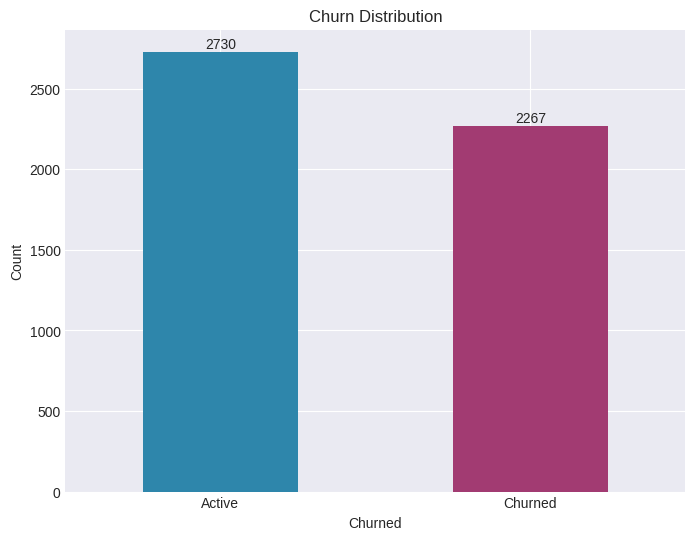

In [18]:
# ============================================
#  Define Churn (Target Variable)
# ============================================

print("="*60)
print("DEFINING CHURN TARGET VARIABLE")
print("="*60)

# Define churn: Customer hasn't purchased in the last X days
# We'll use 90 days as the churn threshold
CHURN_THRESHOLD_DAYS = 90

# Calculate days since last purchase
customer_features['days_since_last_purchase'] = (end_date - customer_features['last_activity']).dt.days

# Create churn label (1 = churned, 0 = active)
customer_features['churned'] = (customer_features['days_since_last_purchase'] > CHURN_THRESHOLD_DAYS).astype(int)

# Also consider if they have 0 purchases
customer_features.loc[customer_features['total_purchases'] == 0, 'churned'] = 1

print(f"Churn defined as: No purchase in last {CHURN_THRESHOLD_DAYS} days")
print(f"Churn distribution:")
print(customer_features['churned'].value_counts(normalize=True) * 100)

# Visualize churn distribution
plt.figure(figsize=(8, 6))
customer_features['churned'].value_counts().plot(kind='bar', color=['#2E86AB', '#A23B72'])
plt.title('Churn Distribution')
plt.xlabel('Churned')
plt.ylabel('Count')
plt.xticks([0, 1], ['Active', 'Churned'], rotation=0)
for i, v in enumerate(customer_features['churned'].value_counts()):
    plt.text(i, v + 5, str(v), ha='center', va='bottom')
plt.show()

In [19]:
# ============================================
# Prepare Data for Modeling
# ============================================

print("="*60)
print("PREPARING DATA FOR PREDICTIVE MODELING")
print("="*60)

# Select features for modeling
features_to_use = [
    'age', 'income', 'total_purchases', 'total_browses', 
    'total_spent', 'avg_order_value', 'total_page_views', 
    'avg_page_views', 'customer_lifetime_days', 
    'purchase_conversion_rate', 'recency', 'frequency', 'monetary'
]

# Create feature matrix (X) and target vector (y)
X = customer_features[features_to_use].copy()
y = customer_features['churned'].copy()

# Handle any remaining missing values
X = X.fillna(X.median())

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Churn rate: {y.mean():.2%}")

# Display feature correlations with target
correlations = X.corrwith(y).sort_values(ascending=False)
print("\nTop features correlated with churn:")
print(correlations.head(10))

print("\nFeatures selected for modeling:")
print(features_to_use)

PREPARING DATA FOR PREDICTIVE MODELING
Feature matrix shape: (4997, 13)
Target vector shape: (4997,)
Churn rate: 45.37%

Top features correlated with churn:
recency                   0.741749
customer_lifetime_days    0.322198
frequency                 0.287648
total_browses             0.230904
monetary                  0.214807
total_page_views          0.190115
total_purchases           0.142096
total_spent               0.112449
age                      -0.014792
income                   -0.035784
dtype: float64

Features selected for modeling:
['age', 'income', 'total_purchases', 'total_browses', 'total_spent', 'avg_order_value', 'total_page_views', 'avg_page_views', 'customer_lifetime_days', 'purchase_conversion_rate', 'recency', 'frequency', 'monetary']


In [20]:
# ============================================
# Save Processed Data
# ============================================

# Save the cleaned and engineered datasets
df.to_csv('ecommerce_cleaned_data.csv', index=False)
customer_features.to_csv('customer_features.csv', index=False)
X.to_csv('X_features.csv', index=False)
pd.DataFrame(y).to_csv('y_target.csv', index=False)

print("="*60)
print("DATA PROCESSING COMPLETE!")
print("="*60)
print("Saved files:")
print("1. ecommerce_cleaned_data.csv - Full cleaned dataset")
print("2. customer_features.csv - Customer-level features")
print("3. X_features.csv - Feature matrix for modeling")
print("4. y_target.csv - Target variable (churn)")

print(f"\nSummary of customer features:")
print(customer_features.describe())

DATA PROCESSING COMPLETE!
Saved files:
1. ecommerce_cleaned_data.csv - Full cleaned dataset
2. customer_features.csv - Customer-level features
3. X_features.csv - Feature matrix for modeling
4. y_target.csv - Target variable (churn)

Summary of customer features:
       customer_id  total_purchases  total_browses  total_spent  \
count  4997.000000      4997.000000    4997.000000  4997.000000   
mean   2500.934561         6.870122     157.788473  1319.533358   
min       1.000000         0.000000       1.000000     0.000000   
25%    1252.000000         3.000000      84.000000   350.310000   
50%    2501.000000         6.000000     164.000000  1056.150000   
75%    3750.000000        10.000000     234.000000  1981.100000   
max    5000.000000        31.000000     310.000000  7697.430000   
std    1443.353751         5.201171      86.127653  1189.502850   

       avg_order_value  total_page_views  avg_page_views  \
count      4997.000000       4997.000000     4997.000000   
mean        

In [21]:
# ============================================
# Train-Test Split
# ============================================

from sklearn.model_selection import train_test_split

print("="*60)
print("TRAIN-TEST SPLIT")
print("="*60)

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Maintains the same churn ratio in both sets
)

print(f"Training set: {X_train.shape[0]:,} customers")
print(f"Testing set: {X_test.shape[0]:,} customers")
print(f"\nTraining churn rate: {y_train.mean():.2%}")
print(f"Testing churn rate: {y_test.mean():.2%}")

# Store feature names for later use
feature_names = X.columns.tolist()

TRAIN-TEST SPLIT
Training set: 3,997 customers
Testing set: 1,000 customers

Training churn rate: 45.36%
Testing churn rate: 45.40%


In [22]:
# ============================================
#  Feature Scaling (Standardization)
# ============================================

from sklearn.preprocessing import StandardScaler

print("="*60)
print("FEATURE SCALING")
print("="*60)

# Initialize scaler
scaler = StandardScaler()

# Fit on training data, transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier interpretation
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_names)

print("Features scaled to mean=0, std=1")
print(f"\nTraining set statistics:")
print(f"Mean: {X_train_scaled_df.mean().mean():.10f}")
print(f"Std: {X_train_scaled_df.std().mean():.2f}")

print("\nFirst 5 rows of scaled training data:")
X_train_scaled_df.head()

FEATURE SCALING
Features scaled to mean=0, std=1

Training set statistics:
Mean: -0.0000000000
Std: 1.00

First 5 rows of scaled training data:


,age,income,total_purchases,total_browses,total_spent,avg_order_value,total_page_views,avg_page_views,customer_lifetime_days,purchase_conversion_rate,recency,frequency,monetary
0,-0.800070,0.281156,0.987851,0.566627,0.340106,0.061440,0.259889,-0.337870,0.789409,0.677927,-0.841370,0.954165,0.273161
1,-1.066676,-1.895042,-1.316238,-1.728010,-1.105618,-1.143912,-1.453897,-1.106925,-2.070000,-1.663170,-0.333246,-0.090082,-0.203983
2,-0.200205,-0.787412,0.219821,1.125726,-0.396566,-0.652029,0.869974,0.204739,0.755470,-0.364546,-0.333246,0.118768,-0.506094
3,-0.866721,0.848550,-0.932223,-0.749586,-0.759684,-0.482070,-0.960282,-1.637823,0.721530,-0.767803,1.746150,-1.134328,-0.890202
4,1.466086,0.023450,-0.164194,-0.772882,0.398079,1.673650,-0.760618,-0.543943,-0.907569,0.967547,-0.755380,-0.298931,0.334485


In [23]:
# ============================================
#  Build Predictive Model - Random Forest
# ============================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import time

print("="*60)
print("RANDOM FOREST MODEL TRAINING")
print("="*60)

# Initialize the model
rf_model = RandomForestClassifier(
    n_estimators=100,        # Number of trees
    max_depth=10,            # Maximum depth of each tree
    min_samples_split=10,    # Minimum samples to split a node
    min_samples_leaf=5,      # Minimum samples in a leaf node
    random_state=42,
    n_jobs=-1                # Use all CPU cores
)

# Train the model
start_time = time.time()
rf_model.fit(X_train_scaled, y_train)
training_time = time.time() - start_time

print(f"Model trained in {training_time:.2f} seconds")
print(f"Number of trees: {rf_model.n_estimators}")
print(f"Feature importance calculated: {rf_model.feature_importances_.shape}")

# Make predictions on training data
y_train_pred = rf_model.predict(X_train_scaled)
y_train_proba = rf_model.predict_proba(X_train_scaled)[:, 1]

print("\nTraining set predictions complete.")

RANDOM FOREST MODEL TRAINING
Model trained in 1.71 seconds
Number of trees: 100
Feature importance calculated: (13,)

Training set predictions complete.


CROSS-VALIDATION
Cross-Validation ROC-AUC Scores: [0.99406169 0.99188683 0.99223106 0.9922437  0.98941669]
Mean ROC-AUC: 0.9920 (±0.0015)

Cross-Validation Accuracy Scores: [0.955      0.95375    0.95619524 0.95994994 0.95244055]
Mean Accuracy: 0.9555 (±0.0026)


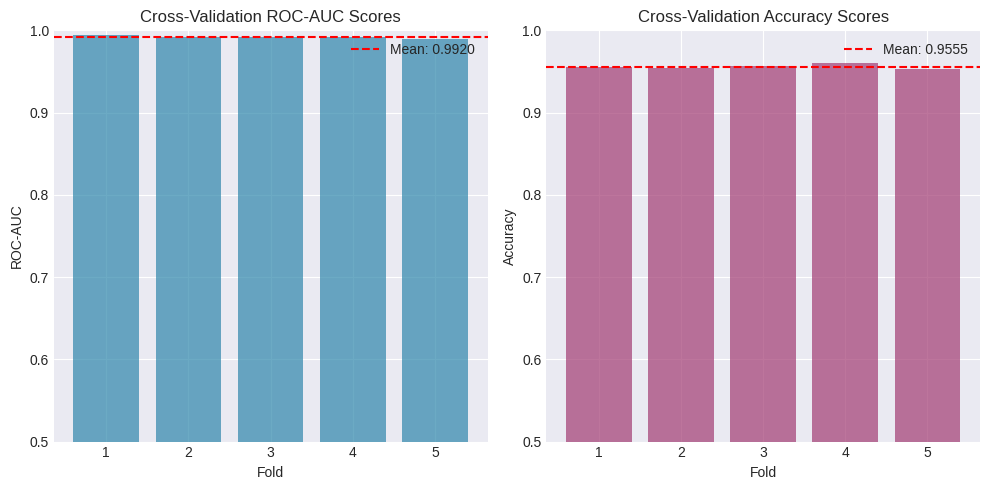

In [24]:
# ============================================
#  Cross-Validation
# ============================================

from sklearn.model_selection import cross_val_score, StratifiedKFold

print("="*60)
print("CROSS-VALIDATION")
print("="*60)

# Perform 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ROC-AUC scores
cv_scores_auc = cross_val_score(rf_model, X_train_scaled, y_train, 
                                 cv=cv, scoring='roc_auc')

# Accuracy scores
cv_scores_accuracy = cross_val_score(rf_model, X_train_scaled, y_train, 
                                      cv=cv, scoring='accuracy')

print(f"Cross-Validation ROC-AUC Scores: {cv_scores_auc}")
print(f"Mean ROC-AUC: {cv_scores_auc.mean():.4f} (±{cv_scores_auc.std():.4f})")

print(f"\nCross-Validation Accuracy Scores: {cv_scores_accuracy}")
print(f"Mean Accuracy: {cv_scores_accuracy.mean():.4f} (±{cv_scores_accuracy.std():.4f})")

# Visualize CV scores
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, 6), cv_scores_auc, color='#2E86AB', alpha=0.7)
plt.axhline(y=cv_scores_auc.mean(), color='red', linestyle='--', label=f'Mean: {cv_scores_auc.mean():.4f}')
plt.title('Cross-Validation ROC-AUC Scores')
plt.xlabel('Fold')
plt.ylabel('ROC-AUC')
plt.ylim(0.5, 1.0)
plt.legend()

plt.subplot(1, 2, 2)
plt.bar(range(1, 6), cv_scores_accuracy, color='#A23B72', alpha=0.7)
plt.axhline(y=cv_scores_accuracy.mean(), color='red', linestyle='--', label=f'Mean: {cv_scores_accuracy.mean():.4f}')
plt.title('Cross-Validation Accuracy Scores')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.ylim(0.5, 1.0)
plt.legend()

plt.tight_layout()
plt.show()

MODEL EVALUATION
Test Set Performance:
Accuracy: 0.9520
ROC-AUC: 0.9936

Classification Report:
              precision    recall  f1-score   support

      Active       0.98      0.93      0.95       546
     Churned       0.92      0.98      0.95       454

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000


Confusion Matrix:
[[509  37]
 [ 11 443]]


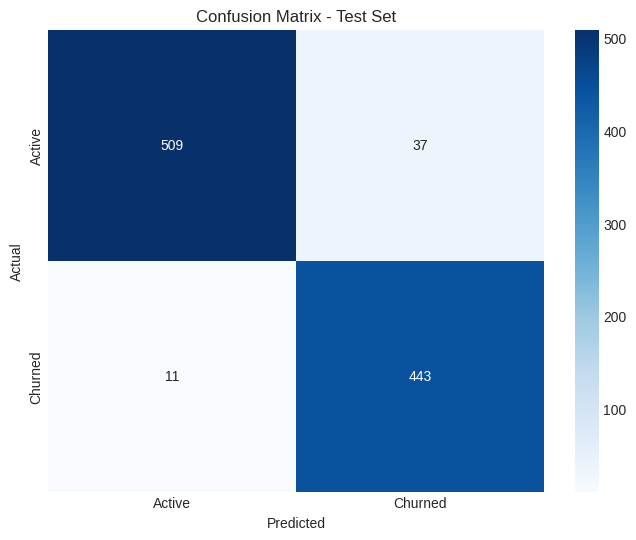

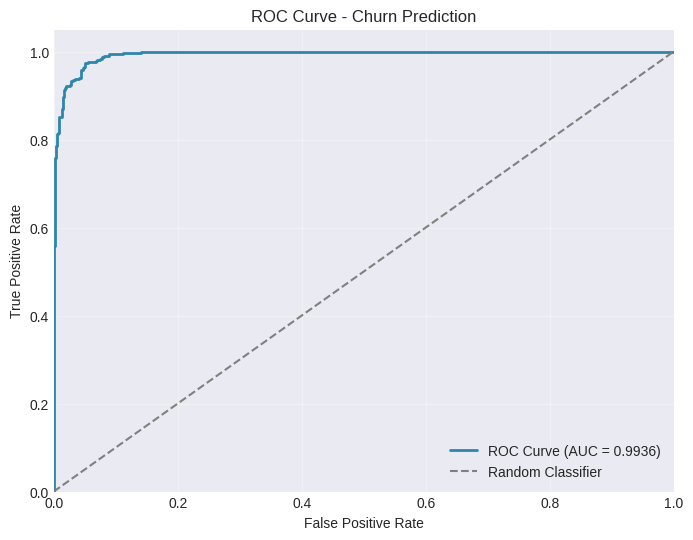

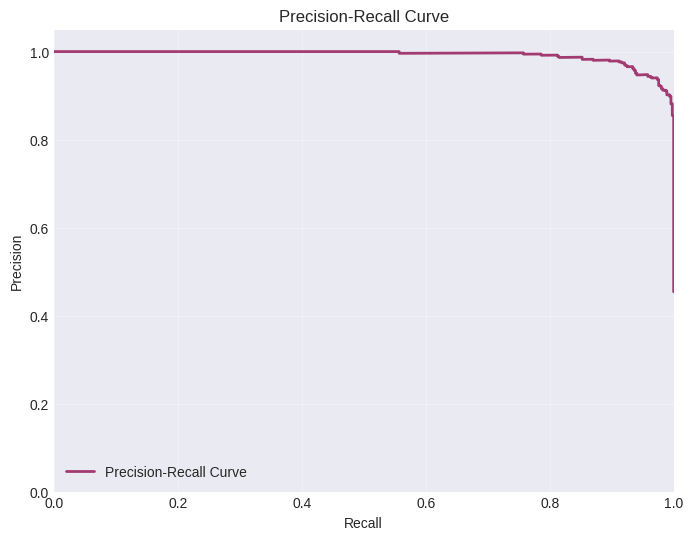

In [25]:
# ============================================
# Model Evaluation
# ============================================

from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, precision_recall_curve)

print("="*60)
print("MODEL EVALUATION")
print("="*60)

# Make predictions on test data
y_test_pred = rf_model.predict(X_test_scaled)
y_test_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
test_accuracy = (y_test_pred == y_test).mean()
test_auc = roc_auc_score(y_test, y_test_proba)

print(f"Test Set Performance:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"ROC-AUC: {test_auc:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Active', 'Churned']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix:")
print(cm)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Active', 'Churned'],
            yticklabels=['Active', 'Churned'])
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
plt.plot(fpr, tpr, color='#2E86AB', lw=2, label=f'ROC Curve (AUC = {test_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Churn Prediction')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# Precision-Recall Curve
plt.figure(figsize=(8, 6))
precision, recall, _ = precision_recall_curve(y_test, y_test_proba)
plt.plot(recall, precision, color='#A23B72', lw=2, label='Precision-Recall Curve')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()

FEATURE IMPORTANCE ANALYSIS
Top 10 Most Important Features:
                     feature  importance
10                   recency    0.540837
8     customer_lifetime_days    0.191379
9   purchase_conversion_rate    0.042318
2            total_purchases    0.041780
5            avg_order_value    0.033303
3              total_browses    0.032082
11                 frequency    0.030126
4                total_spent    0.028195
6           total_page_views    0.020848
7             avg_page_views    0.014320


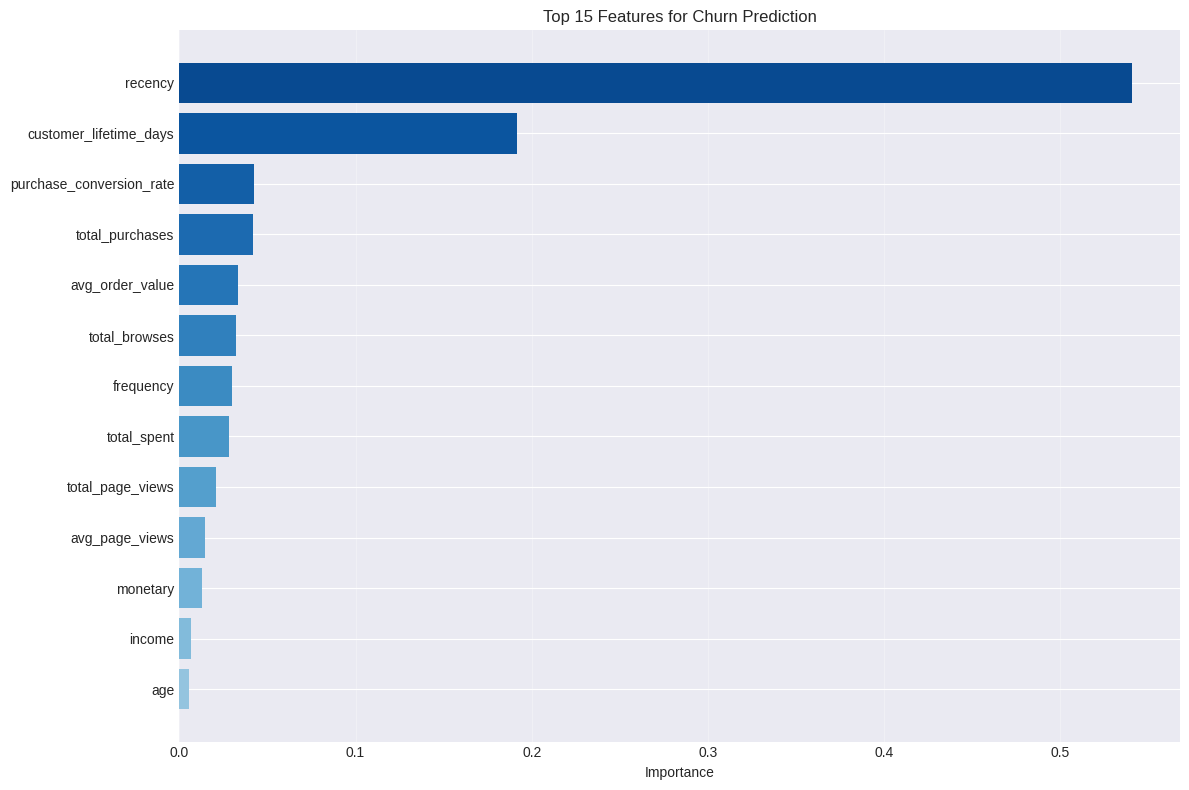


Feature importance saved to 'feature_importance.csv'


In [26]:
# ============================================
#  Feature Importance Analysis
# ============================================

print("="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Get feature importances from Random Forest
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance.head(10))

# Visualize feature importance
plt.figure(figsize=(12, 8))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(feature_importance)))[::-1]
bars = plt.barh(feature_importance['feature'][:15], feature_importance['importance'][:15], color=colors)
plt.xlabel('Importance')
plt.title('Top 15 Features for Churn Prediction')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Save feature importance
feature_importance.to_csv('feature_importance.csv', index=False)
print("\nFeature importance saved to 'feature_importance.csv'")

MODEL COMPARISON


/home/fakunle/miniconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [03:56:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/fakunle/miniconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [03:56:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/fakunle/miniconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [03:56:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/fakunle/miniconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [03:56:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/hom

Model Comparison Results:
              Model CV Mean ROC-AUC Test ROC-AUC
Logistic Regression 0.9891 ± 0.0034       0.9914
      Decision Tree 0.9623 ± 0.0028       0.9612
      Random Forest 0.9914 ± 0.0032       0.9935
            XGBoost 0.9905 ± 0.0028       0.9912


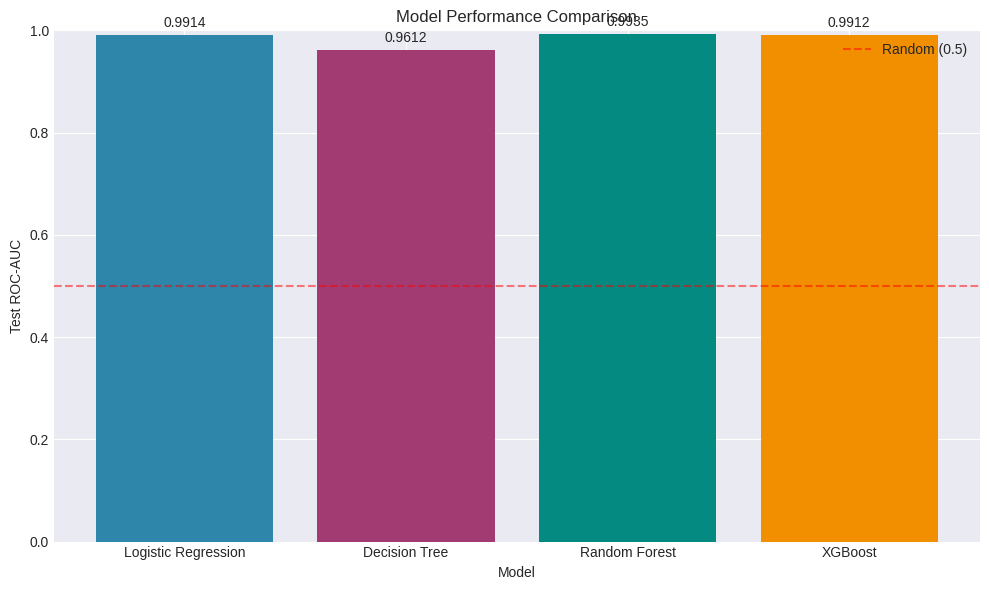

In [29]:
# ============================================
#  Model Comparison (Bonus)
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

print("="*60)
print("MODEL COMPARISON")
print("="*60)

# Define multiple models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=6, random_state=42, use_label_encoder=False, eval_metric='logloss')
}

# Store results
results = []

for name, model in models.items():
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc')
    
    # Train and test
    model.fit(X_train_scaled, y_train)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    test_auc = roc_auc_score(y_test, y_pred_proba)
    
    results.append({
        'Model': name,
        'CV Mean ROC-AUC': f"{cv_scores.mean():.4f} ± {cv_scores.std():.4f}",
        'Test ROC-AUC': f"{test_auc:.4f}"
    })

# Display results
results_df = pd.DataFrame(results)
print("Model Comparison Results:")
print(results_df.to_string(index=False))

# Visualize comparison
plt.figure(figsize=(10, 6))
models_names = [r['Model'] for r in results]
test_aucs = [float(r['Test ROC-AUC']) for r in results]
bars = plt.bar(models_names, test_aucs, color=['#2E86AB', '#A23B72', '#048A81', '#F18F01'])
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random (0.5)')
plt.xlabel('Model')
plt.ylabel('Test ROC-AUC')
plt.title('Model Performance Comparison')
plt.ylim(0, 1)
plt.legend()
for bar, score in zip(bars, test_aucs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.4f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()